# Linear Regression Model - SeoulBikeData.csv

The goal of the model is to predict the number of rented bikes based on key factors, including weather conditions (e.g., temperature, humidity, wind speed), time-related variables (e.g., hour, season, holiday), and operational status (e.g., whether it’s a functioning day).

## 0) Pre-installations

In [2]:
!pip install seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import skew

## 1) Import SeoulBikeData.csv 

In [4]:
import os 

# Change working directory to where you store the Camp files 
os.chdir('~/Desktop/DE_coding_portfolio/3') 

In [5]:
import pandas as pd

# load the data
df = pd.read_csv('~/Desktop/DE_coding_portfolio/3/SeoulBikeData.csv', encoding='ISO-8859-1')

In [6]:
print (df) 

            Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0     01/12/2017                254     0             -5.2           37   
1     01/12/2017                204     1             -5.5           38   
2     01/12/2017                173     2             -6.0           39   
3     01/12/2017                107     3             -6.2           40   
4     01/12/2017                 78     4             -6.0           36   
...          ...                ...   ...              ...          ...   
8755  30/11/2018               1003    19              4.2           34   
8756  30/11/2018                764    20              3.4           37   
8757  30/11/2018                694    21              2.6           39   
8758  30/11/2018                712    22              2.1           41   
8759  30/11/2018                584    23              1.9           43   

      Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0                  2.2      

In [7]:
column_names = df.columns
print(column_names)

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')


In [8]:
# Ensure the 'Date' column in the raw dataset is in datetime format, accounting for day-first format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Find the earliest and latest dates in the raw data
start_date = df['Date'].min()
end_date = df['Date'].max()

# Print the time frame
print(f"The dataset covers the time frame from {start_date} to {end_date}.")

The dataset covers the time frame from 2017-12-01 00:00:00 to 2018-11-30 00:00:00.


## 2) Data Filtering and Preprocessing

In [9]:
# Filter the data by removing empty values
df_filtered = df.dropna()

# Encode categorical variables using LabelEncoder
categorical_columns = ['Seasons', 'Holiday', 'Functioning Day']  # Categorical columns: Winter,1 ; Spring,2 ; Summer,3 ; Autumn,4 ; No Holiday,0 ; Holiday,1 ; No,0 ; Yes,1
for col in categorical_columns:
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col])

# Normalize numerical columns - continuous variables
numerical_columns = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',   
                     'Visibility (10m)', 'Dew point temperature(°C)', 
                     'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Hour']
scaler = StandardScaler()      # Normalize the numerical columns to the same scale (mean=0, std=1)
df_filtered[numerical_columns] = scaler.fit_transform(df_filtered[numerical_columns])

# Select the relevant columns for regression analysis
df_filtered = df_filtered[['Rented Bike Count'] + numerical_columns + categorical_columns]

# Print the filtered and processed dataset
print(df_filtered.head())

   Rented Bike Count  Temperature(°C)  Humidity(%)  Wind speed (m/s)  \
0                254        -1.513957    -1.042483          0.458476   
1                204        -1.539074    -0.993370         -0.892561   
2                173        -1.580936    -0.944257         -0.699556   
3                107        -1.597680    -0.895144         -0.796059   
4                 78        -1.580936    -1.091596          0.554978   

   Visibility (10m)  Dew point temperature(°C)  Solar Radiation (MJ/m2)  \
0          0.925871                  -1.659605                -0.655132   
1          0.925871                  -1.659605                -0.655132   
2          0.925871                  -1.667262                -0.655132   
3          0.925871                  -1.659605                -0.655132   
4          0.925871                  -1.736177                -0.655132   

   Rainfall(mm)  Snowfall (cm)      Hour  Seasons  Holiday  Functioning Day  
0       -0.1318      -0.171891 -1.6613

- Rented Bike Count: Target variable (what we want to predict)

- Categorical variables (Seasons, Holiday, Functioning Day) have been converted into numerical formats using Label Encoder.
- All numerical columns (e.g., Temperature, Humidity, Wind, Speed have been normalized using StandardScaler). Hence all the values are now on a standardized scale with a mean of 0 and a standard deviation of 1

- Temperature: normalized value --> ex) -1.514~ at this time is about 1.5 standard devation below the average.

## 3) Bike Rental Demand Regression

In [10]:
# Define independent (X) and dependent (y) variables
# Combine categorical and numerical features as predictors
X = df_filtered[['Seasons', 'Holiday', 'Functioning Day'] + 
                 ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 
                  'Visibility (10m)', 'Dew point temperature(°C)', 
                  'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Hour']]

# Define the target variable
y = df_filtered['Rented Bike Count']

# Add a constant to the features to account for the intercept in the model
X = sm.add_constant(X)

# Fit the OLS regression model
ols_model = sm.OLS(y, X).fit()

# Display the summary of the model
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     888.4
Date:                Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                        22:05:32   Log-Likelihood:                -65609.
No. Observations:                8760   AIC:                         1.312e+05
Df Residuals:                    8747   BIC:                         1.313e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### Key Insights from Bike Rental Demand Regression 

1. **Model Fit**:
   - The model explains 65.9% of the variation in bike rentals (R-squared=0.549).

2. **Weather Effects**:
   - Higher temperature increases (+206.84 bikes / °C).
   - Humidity (-222.95 bikes / %) and rain fall (-65.45 bikes / mn) reduces rentals.
   - Better visibility slightly increases rental (+13.07 bikes).

3. **Operational Factorse**:
   - Rentals are 935.39 bikes higher on functioning days.
   - Holiday increases rentals by 125.39 bikes.

4. **Seasonality**:
   - Rentals are lower in Summer compared to the baseline season.

## 4) Posterior Distributions
- A posterior distribution represents the range of possible values for model parameters based on observed data and uncertainty. This will allow us to quantify the variability of each coefficient and how confident we are about the effects of variates on bike rentals.

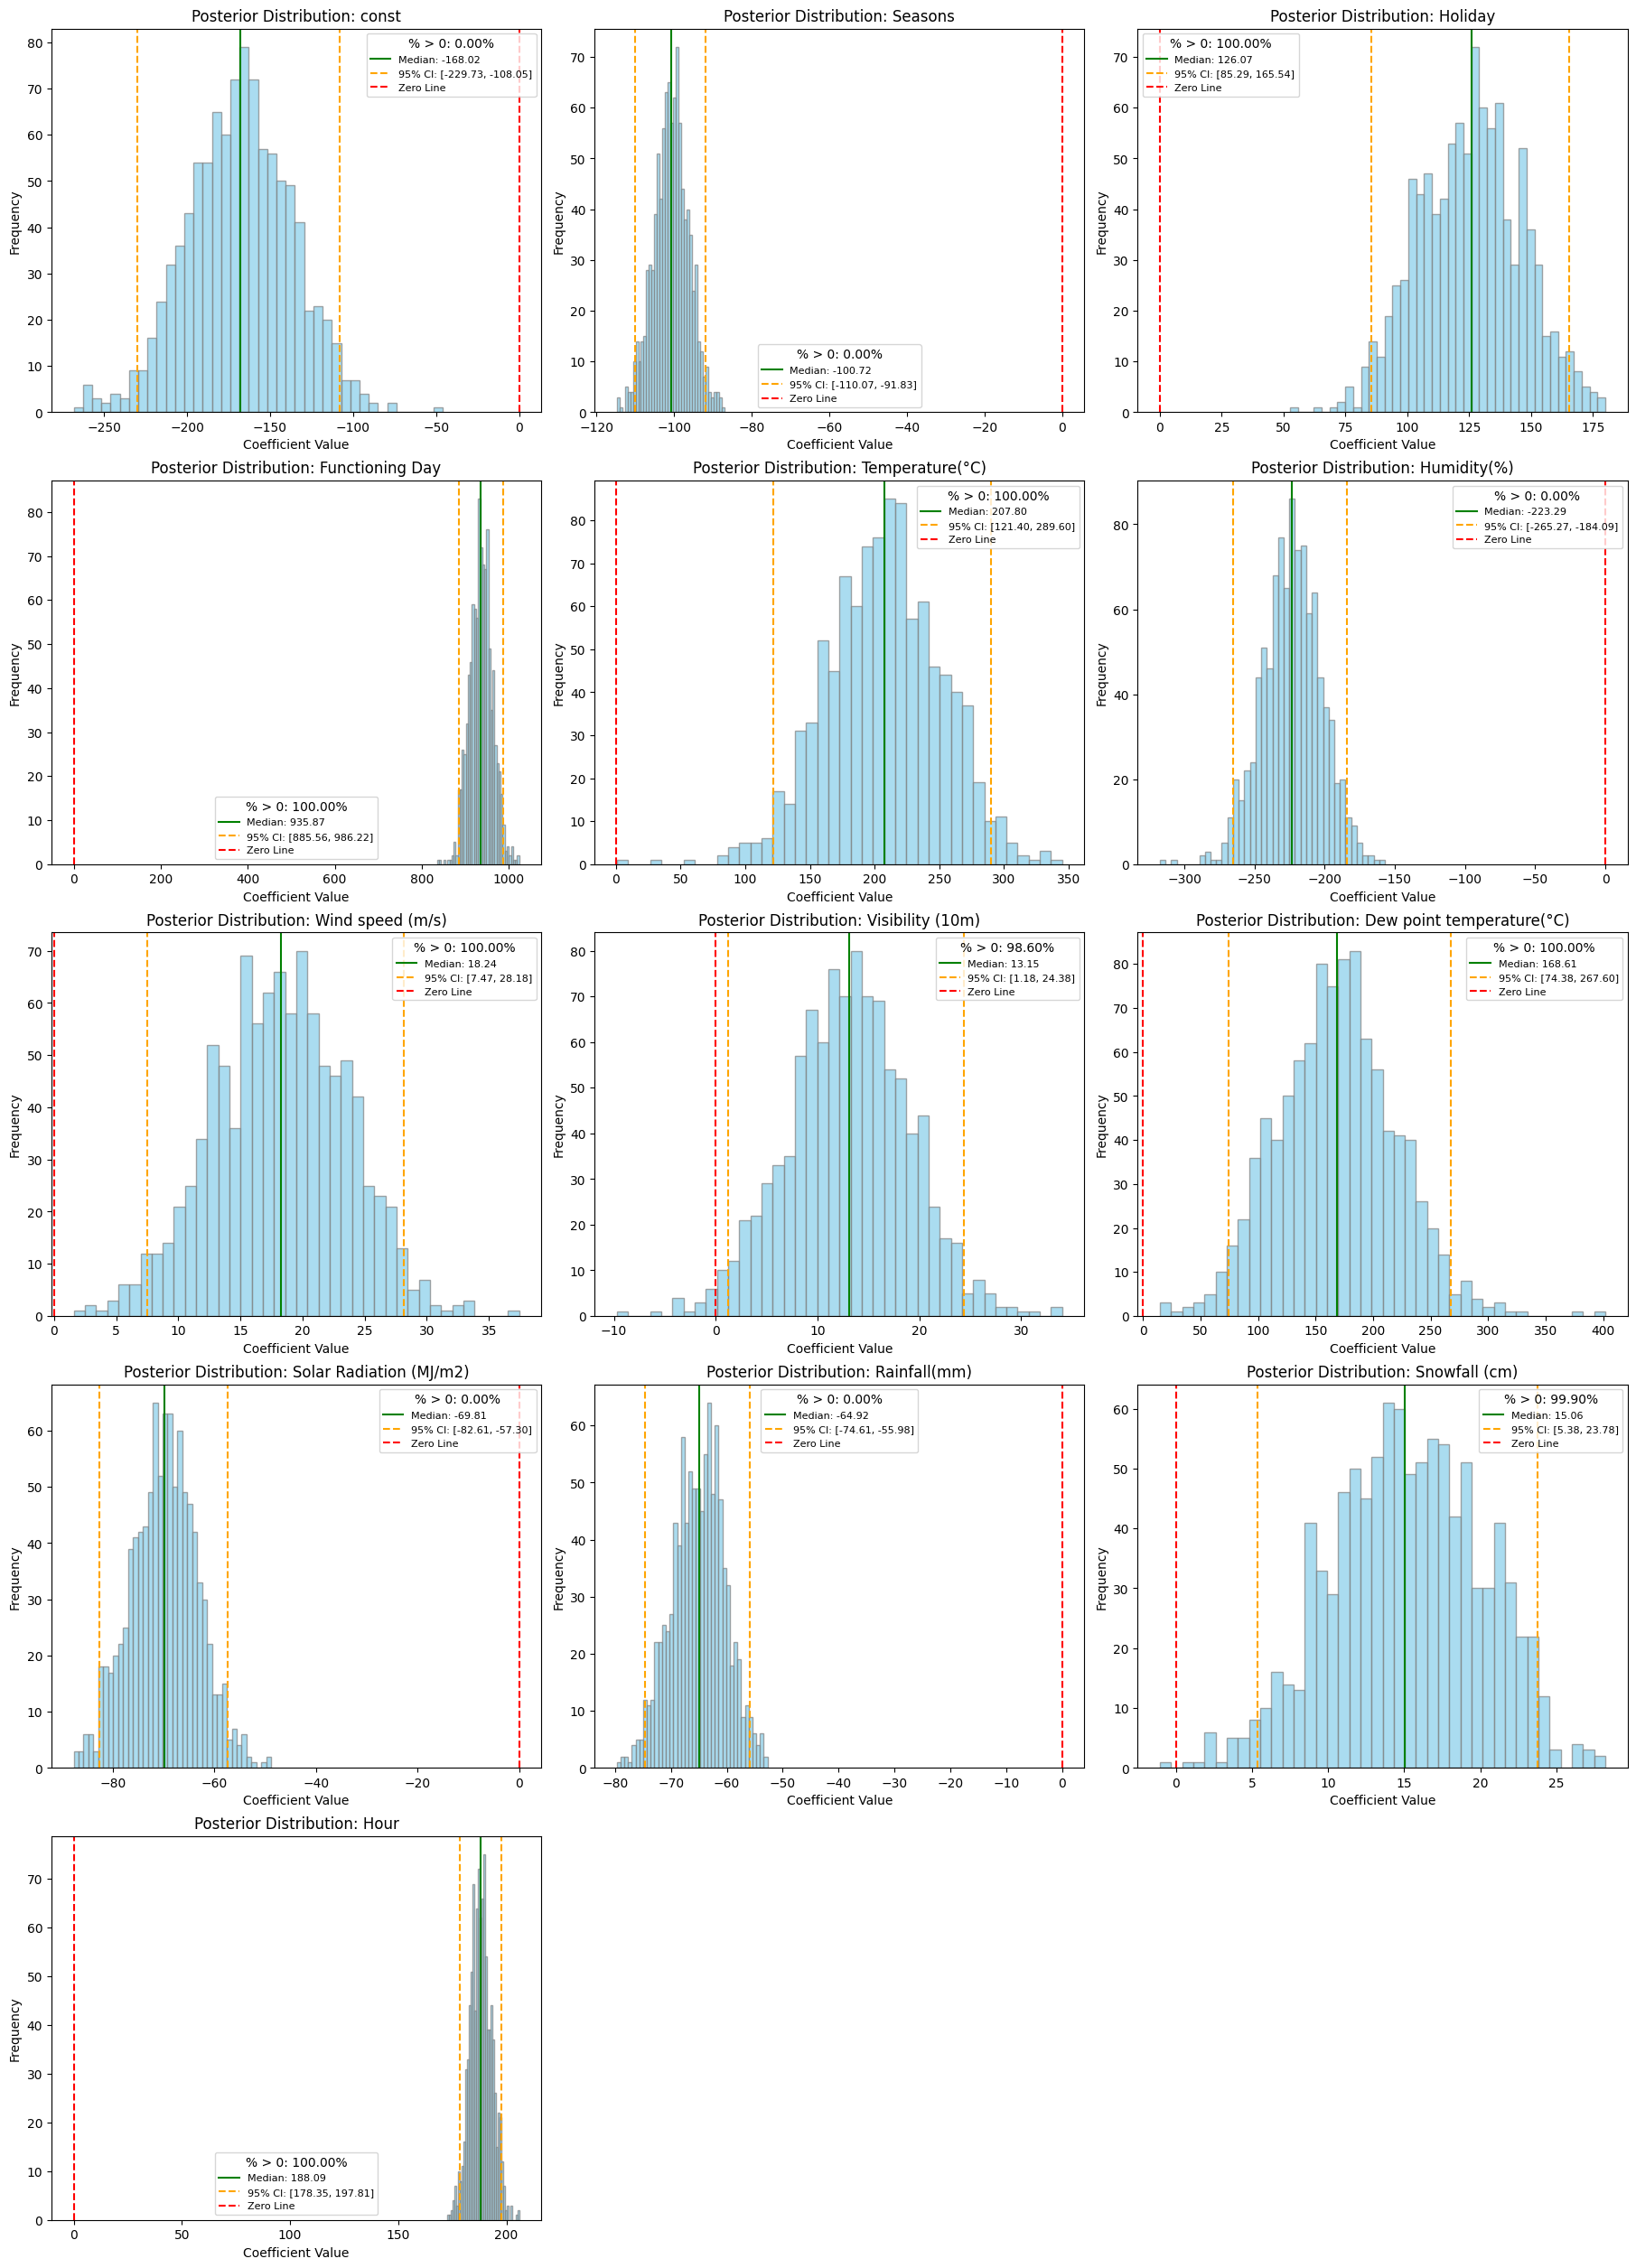

In [11]:
# Simulate values from the posterior distribution of coefficients
coeff_samples = np.random.multivariate_normal(ols_model.params, ols_model.cov_params(), 1000)

# Extract parameter names and count
parameter_names = ols_model.params.index.tolist()
n_params = len(parameter_names)

# Dynamic subplot grid
n_cols = min(3, n_params)  # Maximum of 3 plots per row
n_rows = (n_params + n_cols - 1) // n_cols  # Adjust rows dynamically

# Create the subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), constrained_layout=True)
axes_flat = axes.flatten()  # Flatten axes array for easy iteration

# Plot histograms for each coefficient
for i, name in enumerate(parameter_names):
    mean_val = np.mean(coeff_samples[:, i])  # Mean of simulated values
    median_val = np.median(coeff_samples[:, i])  # Median of simulated values
    ci_lower, ci_upper = np.percentile(coeff_samples[:, i], [2.5, 97.5])  # 95% CI
    percent_positive = np.mean(coeff_samples[:, i] > 0) * 100  # Percentage > 0

    # Histogram plot
    ax = axes_flat[i]
    ax.hist(coeff_samples[:, i], bins=40, color='skyblue', edgecolor='gray', alpha=0.7)
    ax.axvline(x=median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    ax.axvline(x=ci_lower, color='orange', linestyle='--', label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
    ax.axvline(x=ci_upper, color='orange', linestyle='--')
    ax.axvline(x=0, color='red', linestyle='--', label='Zero Line')

    # Plot aesthetics
    ax.set_title(f'Posterior Distribution: {name}', fontsize=12)
    ax.set_xlabel('Coefficient Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(title=f'% > 0: {percent_positive:.2f}%', fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Show the plot
plt.show()

### Key Insights from Posterior Distributions

1. **Constant (intercept)**: expected number of bike rentals when all predictors are at their baseline values 
   - The intercept is negative and far from zero line which suggests that without considering predictors, the model predics negative bike rentals.
   - This is not that meaningful by itself but serves as a baseline for interpretations. 

2. **Seasons**:
   - Seasons have a consistently negative effect on bike rentals compared to the baseline (likely winter).
   - This complements the role of seasonality in reducing demand. 

3. **Holiday**:
   - Holidays positively impact bike rentals as all the interval is above zero line. This confirms a significant positive effect. 

4. **Functioning Day**:
   - Rentals increase significantly on functioning days. A strong positive effect. 

5. **Temperature (°C)**:
   - Warmer temperatures strongly drive bike rentals, indicating a positive effect. 

6. **Humidity (%)**:
   - Humidity significantly decreases bike rentals. 
   - This effect is likely aligned with discomfort caused by high humidity levels.

7. **Wind Speed (m/s)**:
   - Wind speed has a small but consistent positive impact.
   - This suggest that mild winds might be favorable for biking. 

8. **Visibility (10m)**:
   - Higher visibility marginally increase rentals.

9. **Dew Point Temperature (°C)**: 
   - Dew point temperature has positive effect on rentals. 

10. **Solar Radiation**:
   - Higher solar radiation negatively impacts rental.

11. **Rainfall (nm)**:
   - Rainfall substantially reduces rentals, as all the coefficient values are distributed far belowthe zero line. 

12. **Snowfall (cm)**:
   - Notably, snowfall increases rentals marginally.
   - This maybe a context-specific phenomenon, such as winter biking activity. 

13. **Hour**:
   - Bike rentals increases during specific hours.
   - This suggest the importance of time in predicting user demand patterns. 

## 5) Generate Predicted Values and Estimate Statistics

- Model's confidence range for bike rental demand

In [12]:
import numpy as np
import statsmodels.api as sm

# Add an intercept to the design matrix (if not already present)
X_new_with_const = sm.add_constant(X)  # X is the design matrix (independent variables)

# Simulate fitted values by multiplying sampled coefficients with design matrix
fitted_value_samples = X_new_with_const @ coeff_samples.T  # X * coeff_samples.T

# Calculate the median of fitted values and 95% prediction intervals
monte_carlo_medians = np.median(fitted_value_samples, axis=1)
prediction_intervals = np.percentile(fitted_value_samples, [2.5, 97.5], axis=1)

# Output results
print("Median of fitted values (per observation):", monte_carlo_medians)
print("95% Prediction intervals:", prediction_intervals)

Median of fitted values (per observation): [  -9.78564704  -22.71883944  -12.93465654 ... 1041.75918081 1049.39785461
 1063.96737212]
95% Prediction intervals: [[ -38.20564851  -50.97031871  -40.28365459 ... 1010.07911221
  1020.63816904 1035.95640229]
 [  17.84903783    3.24981838   11.9690894  ... 1073.79468814
  1079.88912589 1095.37418806]]


In [13]:
# Calculate metrics
correlation = np.corrcoef(monte_carlo_medians, y)[0, 1]  # Pearson correlation coefficient
rmse = np.sqrt(mean_squared_error(y, monte_carlo_medians))  # Root Mean Squared Error
bias = np.mean(monte_carlo_medians - y)  # Bias: Mean difference between predicted and observed values
coverage = np.mean((y >= prediction_intervals[0, :]) & (y <= prediction_intervals[1, :]))  # Coverage of 95% prediction intervals

# Calculate min and max values for plotting
min_val = min(y.min(), monte_carlo_medians.min())  # Minimum value for the plot range
max_val = max(y.max(), monte_carlo_medians.max())  # Maximum value for the plot range

- Monte Carlo medians represents the central tendency of the predicted values from posterior distributions. 
- RMSE measures the average error between the observed values (y) and the predicted means (monte carlo medians)
    - Lower RMSE imply that model's predictions are closer to the actual observations. 


In [15]:
rmse

432.9824416469244

- The model's prediction deviate by about 433 rentals on average. 
- This suggests it captures general trends well but struggles with large fluctuations in bike rental demand. 
- This may be due to variability of factors that are not accounted in the dataset. 

###  Observed values vs. Predicted Bike Rental (Monte Carlo Medians)

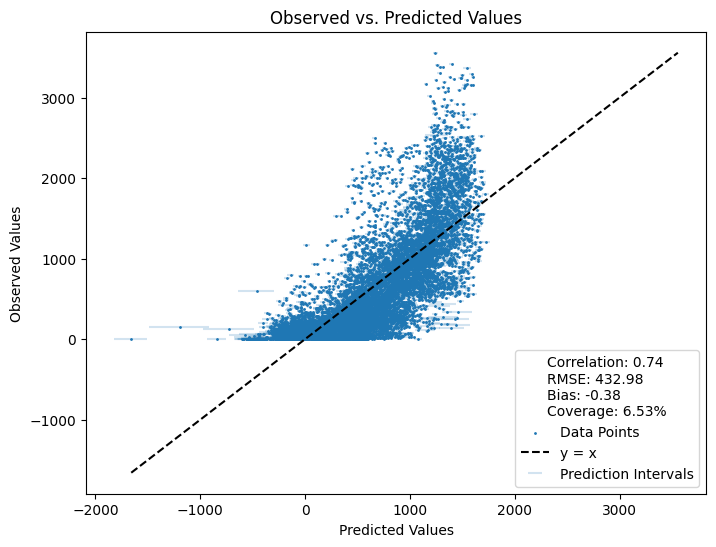

In [16]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(monte_carlo_medians, y, s=1, alpha=1, label='Data Points')
plt.errorbar(
    monte_carlo_medians,
    y,
    xerr=[monte_carlo_medians - prediction_intervals[0, :], prediction_intervals[1, :] - monte_carlo_medians],
    fmt='none',
    alpha=0.2,
    label='Prediction Intervals'
)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x')

# Add metrics to legend
legend_text = (
    f'Correlation: {correlation:.2f}\n'
    f'RMSE: {rmse:.2f}\n'
    f'Bias: {bias:.2f}\n'
    f'Coverage: {coverage:.2%}'
)
plt.legend(title=legend_text, loc='lower right')

# Labeling
plt.title('Observed vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Observed Values')

# Display plot
plt.show()

#### Most points cluster near the line, but noticeable deviations occur for higher rental counts.

1. **Correlation (0.74)**: 
- There is a strong positive correlation, indicating the model captures the general trend of bike rental demands well. 

2. **RMSE (432.98)**: 
- On average, predictions deviate by approximately 433 rentals from actual values. 

3. **Bias (-0.38)**: 
- The model slightly underestimates bike rentals on average. 

4. **Coverage (6.53%)**:
- The 95% prediction intervals only cover a small percentage of actual values.
- This implies that the model underestimates uncertainty in its predictions.

